# 13_model_training_tcn.ipynb — Modelo temporal TCN para DeepWave Canarias

Este notebook entrena un modelo profundo tipo **TCN (Temporal Convolutional Network)** sobre:

```text
gold/training_dataset/
```

Objetivo:

```text
Usar secuencias temporales de las últimas 24 horas para predecir hs futura.
```

Horizontes:

```text
+3h
+6h
+12h
+24h
```

Modelo:

```text
TCN multisalida
input  = secuencia [últimas 24h × features]
output = [target_hs_3h, target_hs_6h, target_hs_12h, target_hs_24h]
```

Después, el riesgo se deriva desde la hs predicha:

```text
predicted_hs → predicted_risk
```

Salidas:

```text
models/tcn/
gold/model_results/tcn/
```

Este notebook permite comparar el enfoque secuencial con los modelos tabulares ya entrenados:

```text
LightGBMRegressor
XGBClassifier
Persistence
```

> Versión revisada: Colab-safe, con generador de secuencias para evitar reinicios por RAM.

## Celda 0 — Montar Google Drive

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## Celda 1 — Instalar librerías

In [2]:
!pip -q install pandas numpy pyarrow scikit-learn matplotlib joblib tqdm

## Celda 2 — Imports, rutas y configuración

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import pyarrow.dataset as ds
import pyarrow.parquet as pq
import json
import joblib
import shutil
import gc
import warnings
from tqdm.auto import tqdm

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except Exception as e:
    raise ImportError(
        "No se pudo importar TensorFlow. En Google Colab suele venir instalado. "
        "Si falla, ejecuta: !pip install tensorflow"
    ) from e

# Evitar que TensorFlow reserve de golpe toda la GPU si Colab la tiene activa.
try:
    gpus = tf.config.list_physical_devices("GPU")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
except Exception as e:
    print("Aviso: no se pudo activar memory_growth:", repr(e))

BASE_DIR = Path("/content/drive/MyDrive/AI Projects/DeepWave Canarias")
GOLD_DIR = BASE_DIR / "gold"
GOLD_TRAINING_DIR = GOLD_DIR / "training_dataset"

MODELS_DIR = BASE_DIR / "models" / "tcn"
RESULTS_DIR = GOLD_DIR / "model_results" / "tcn"

for d in [MODELS_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

HORIZONS_HOURS = [3, 6, 12, 24]
TARGET_COLS = [f"target_hs_{h}h" for h in HORIZONS_HOURS]
RISK_CLASSES = [0, 1, 2, 3]

RISK_THRESHOLDS = {
    "low_max": 1.0,
    "moderate_max": 2.0,
    "high_max": 3.0,
}

# -------------------------------------------------------------------------
# CONFIGURACIÓN COLAB-SAFE
# -------------------------------------------------------------------------
# Esta versión está pensada para evitar reinicios de RAM en Colab.
# Primero entrena una muestra controlada. Si va bien, se pueden subir límites.
SEQUENCE_LENGTH = 24
BATCH_SIZE = 128
EPOCHS = 30
PATIENCE = 5
RANDOM_STATE = 42

USE_COMMON_ZONES_ONLY = True

# Muestra controlada para no explotar RAM.
# Para Colab con poca RAM, bajar a 80000 / 15000 / 25000.
MAX_TRAIN_SEQUENCES = 120000
MAX_VAL_SEQUENCES = 25000
MAX_TEST_SEQUENCES = 40000

# Límite de features dinámicas para mantener compacto el tensor temporal.
MAX_TCN_FEATURES = 44

# Arquitectura ligera.
TCN_FILTERS = 24
TCN_DILATIONS = [1, 2, 4, 8]
TCN_DROPOUT = 0.10
DENSE_UNITS_1 = 48
DENSE_UNITS_2 = 24

# Features con demasiados nulos se excluyen.
MAX_MISSING_PCT_FEATURE = 98.0

# No usar zona_id como feature para evitar memorizar identificadores.
USE_ZONA_ID_AS_FEATURE = False

# Features dinámicas/principales para secuencia.
# El notebook selecciona automáticamente, pero prioriza estas si existen.
PREFERRED_SEQUENCE_FEATURES = [
    "simar_hs",
    "simar_tp",
    "simar_tm02",
    "simar_wave_direction",
    "simar_swell_height",
    "simar_swell_period",
    "simar_swell_direction",
    "simar_wind_wave_height",
    "simar_wind_speed",
    "simar_wind_direction",
    "simar_u10",
    "simar_v10",
    "simar_current_speed",
    "simar_current_direction",
    "simar_sst",
    "simar_salinity",
    "redmar_sea_level",
    "redmar_astronomical_tide",
    "redmar_meteorological_residual",
    "redmar_daily_tidal_range",
    "redmar_hours_to_high_tide",
    "redmar_hours_to_low_tide",
    "aemet_temperature_air",
    "aemet_precipitation",
    "aemet_wind_speed",
    "aemet_pressure",
    "lat",
    "lon",
    "depth_100m",
    "depth_500m",
    "depth_1km",
    "depth_2km",
    "mean_depth_1km",
    "slope_0_500m",
    "slope_500m_2km",
    "distance_to_10m_isobath",
    "distance_to_20m_isobath",
    "bathymetry_roughness",
    "exposicion_norte",
    "exposicion_oeste",
    "exposicion_este",
    "exposicion_swell_nw",
    "exposicion_swell_ne",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "dayofyear_sin",
    "dayofyear_cos",
]

# Categóricas que codificaremos como número.
CATEGORICAL_CANDIDATES = [
    "isla",
    "orientacion_costa",
    "redmar_tide_phase",
]

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))
print("GOLD_TRAINING_DIR:", GOLD_TRAINING_DIR)
print("Existe:", GOLD_TRAINING_DIR.exists())
print("Configuración Colab-safe:")
print("  BATCH_SIZE:", BATCH_SIZE)
print("  MAX_TRAIN_SEQUENCES:", MAX_TRAIN_SEQUENCES)
print("  MAX_VAL_SEQUENCES:", MAX_VAL_SEQUENCES)
print("  MAX_TEST_SEQUENCES:", MAX_TEST_SEQUENCES)
print("  MAX_TCN_FEATURES:", MAX_TCN_FEATURES)
print("  TCN_FILTERS:", TCN_FILTERS)

if not GOLD_TRAINING_DIR.exists():
    raise FileNotFoundError("No existe gold/training_dataset/. Ejecuta primero 11_gold_training_dataset.ipynb.")

TensorFlow: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GOLD_TRAINING_DIR: /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/training_dataset
Existe: True
Configuración Colab-safe:
  BATCH_SIZE: 128
  MAX_TRAIN_SEQUENCES: 120000
  MAX_VAL_SEQUENCES: 25000
  MAX_TEST_SEQUENCES: 40000
  MAX_TCN_FEATURES: 44
  TCN_FILTERS: 24


## Celda 3 — Funciones auxiliares

In [4]:
def ensure_utc(series):
    return pd.to_datetime(series, utc=True, errors="coerce")


def risk_level_from_hs(values):
    values = pd.Series(np.asarray(values), dtype="float64")
    risk = pd.Series(np.nan, index=values.index, dtype="float64")

    risk.loc[values < RISK_THRESHOLDS["low_max"]] = 0
    risk.loc[(values >= RISK_THRESHOLDS["low_max"]) & (values < RISK_THRESHOLDS["moderate_max"])] = 1
    risk.loc[(values >= RISK_THRESHOLDS["moderate_max"]) & (values < RISK_THRESHOLDS["high_max"])] = 2
    risk.loc[values >= RISK_THRESHOLDS["high_max"]] = 3

    return risk.astype("Int64")


def regression_metrics(y_true, y_pred):
    y_true = pd.Series(np.asarray(y_true), dtype="float64")
    y_pred = pd.Series(np.asarray(y_pred), dtype="float64")

    mask = y_true.notna() & y_pred.notna()

    if mask.sum() == 0:
        return {
            "n": 0,
            "mae": np.nan,
            "rmse": np.nan,
            "r2": np.nan,
            "bias": np.nan,
            "corr": np.nan,
        }

    yt = y_true[mask].values
    yp = y_pred[mask].values

    return {
        "n": int(mask.sum()),
        "mae": float(mean_absolute_error(yt, yp)),
        "rmse": float(np.sqrt(mean_squared_error(yt, yp))),
        "r2": float(r2_score(yt, yp)) if len(np.unique(yt)) > 1 else np.nan,
        "bias": float(np.mean(yp - yt)),
        "corr": float(np.corrcoef(yt, yp)[0, 1]) if len(yt) > 1 and np.std(yt) > 0 and np.std(yp) > 0 else np.nan,
    }


def classification_metrics(y_true, y_pred):
    y_true = pd.Series(np.asarray(y_true), dtype="Int64")
    y_pred = pd.Series(np.asarray(y_pred), dtype="Int64")

    mask = y_true.notna() & y_pred.notna()

    if mask.sum() == 0:
        out = {
            "n": 0,
            "accuracy": np.nan,
            "balanced_accuracy": np.nan,
            "macro_f1": np.nan,
            "weighted_f1": np.nan,
        }

        for cls in RISK_CLASSES:
            out[f"precision_class_{cls}"] = np.nan
            out[f"recall_class_{cls}"] = np.nan
            out[f"f1_class_{cls}"] = np.nan
            out[f"support_class_{cls}"] = 0

        return out

    yt = y_true[mask].astype(int).values
    yp = y_pred[mask].astype(int).values

    precision, recall, f1, support = precision_recall_fscore_support(
        yt,
        yp,
        labels=RISK_CLASSES,
        zero_division=0,
    )

    out = {
        "n": int(mask.sum()),
        "accuracy": float(accuracy_score(yt, yp)),
        "balanced_accuracy": float(balanced_accuracy_score(yt, yp)),
        "macro_f1": float(f1_score(yt, yp, labels=RISK_CLASSES, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(yt, yp, labels=RISK_CLASSES, average="weighted", zero_division=0)),
    }

    for i, cls in enumerate(RISK_CLASSES):
        out[f"precision_class_{cls}"] = float(precision[i])
        out[f"recall_class_{cls}"] = float(recall[i])
        out[f"f1_class_{cls}"] = float(f1[i])
        out[f"support_class_{cls}"] = int(support[i])

    return out


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False, default=str)


def memory_report(name, df):
    mb = df.memory_usage(deep=True).sum() / 1024 / 1024
    print(f"{name}: shape={df.shape}, memoria≈{mb:.1f} MB")


def sample_indices(n, max_n):
    if max_n is None or n <= max_n:
        return np.arange(n)
    rng = np.random.default_rng(RANDOM_STATE)
    return np.sort(rng.choice(np.arange(n), size=max_n, replace=False))


def plot_history(history):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(9, 5))
    plt.plot(hist["loss"], label="train loss")
    if "val_loss" in hist.columns:
        plt.plot(hist["val_loss"], label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Curva de entrenamiento TCN")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "plot_training_history_loss.png", dpi=160)
    plt.show()

    if "mae" in hist.columns:
        plt.figure(figsize=(9, 5))
        plt.plot(hist["mae"], label="train mae")
        if "val_mae" in hist.columns:
            plt.plot(hist["val_mae"], label="val mae")
        plt.xlabel("Epoch")
        plt.ylabel("MAE")
        plt.title("Curva MAE TCN")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / "plot_training_history_mae.png", dpi=160)
        plt.show()

## Celda 4 — Cargar Gold training dataset

In [5]:
dataset = ds.dataset(str(GOLD_TRAINING_DIR), format="parquet", partitioning="hive")
gold = dataset.to_table().to_pandas()

gold["timestamp"] = ensure_utc(gold["timestamp"])
gold["split"] = gold["split"].astype(str)

print("Gold cargado:")
memory_report("gold", gold)

print("Splits:")
display(gold["split"].value_counts(dropna=False).reset_index())

print("Rango temporal:")
print(gold["timestamp"].min(), "→", gold["timestamp"].max())

print("Zonas:", gold["zona_id"].nunique())
display(gold.head())

Gold cargado:
gold: shape=(983328, 142), memoria≈1552.1 MB
Splits:


,split,count
0,train,698712
1,test,197256
2,val,87360


Rango temporal:
2015-01-01 00:00:00+00:00 → 2025-12-31 23:00:00+00:00
Zonas: 14


,timestamp,zona_id,simar_ocean_lat,simar_ocean_lon,simar_hs,simar_hmax,simar_tp,simar_tm02,simar_wave_direction,simar_swell_height,...,target_risk_24h,gold_dataset_version,target_source,risk_threshold_low_max,risk_threshold_moderate_max,risk_threshold_high_max,has_any_target,is_trainable_target_3h,split,year
0,2024-01-01 00:00:00+00:00,CAN_FV_GRAN_TARAJAL,28.166667,-14.0,0.14,NaN,14.66,2.49,129,0.06,...,0,v1_silver_validated_simar_target,SIMAR,1.0,2.0,3.0,True,1,test,2024
1,2024-01-01 01:00:00+00:00,CAN_FV_GRAN_TARAJAL,28.166667,-14.0,0.14,NaN,14.66,2.57,270,0.06,...,0,v1_silver_validated_simar_target,SIMAR,1.0,2.0,3.0,True,1,test,2024
2,2024-01-01 02:00:00+00:00,CAN_FV_GRAN_TARAJAL,28.166667,-14.0,0.14,NaN,14.66,2.63,283,0.07,...,0,v1_silver_validated_simar_target,SIMAR,1.0,2.0,3.0,True,1,test,2024
3,2024-01-01 03:00:00+00:00,CAN_FV_GRAN_TARAJAL,28.166667,-14.0,0.15,NaN,14.66,2.53,303,0.07,...,0,v1_silver_validated_simar_target,SIMAR,1.0,2.0,3.0,True,1,test,2024
4,2024-01-01 04:00:00+00:00,CAN_FV_GRAN_TARAJAL,28.166667,-14.0,0.17,NaN,16.12,2.30,32,0.08,...,0,v1_silver_validated_simar_target,SIMAR,1.0,2.0,3.0,True,1,test,2024


## Celda 5 — Filtrar zonas comunes train/val/test

In [6]:
if USE_COMMON_ZONES_ONLY:
    zones_by_split = {
        split: set(gold.loc[gold["split"] == split, "zona_id"].dropna().astype(str).unique())
        for split in ["train", "val", "test"]
    }

    common_zones = set.intersection(*zones_by_split.values())

    print("Zonas train:", len(zones_by_split["train"]))
    print("Zonas val:", len(zones_by_split["val"]))
    print("Zonas test:", len(zones_by_split["test"]))
    print("Zonas comunes:", len(common_zones))

    if len(common_zones) == 0:
        raise ValueError("No hay zonas comunes entre train/val/test.")

    before = len(gold)
    gold = gold[gold["zona_id"].astype(str).isin(common_zones)].copy()
    after = len(gold)

    print(f"Filtrado a zonas comunes: {before:,} → {after:,} filas")

else:
    common_zones = set(gold["zona_id"].dropna().astype(str).unique())
    print("Se usan todas las zonas:", len(common_zones))

split_zone_summary = (
    gold.groupby("split", as_index=False)
    .agg(
        rows=("zona_id", "size"),
        zones=("zona_id", "nunique"),
        timestamp_min=("timestamp", "min"),
        timestamp_max=("timestamp", "max"),
    )
)

display(split_zone_summary)
split_zone_summary.to_csv(RESULTS_DIR / "split_zone_summary.csv", index=False)

Zonas train: 10
Zonas val: 10
Zonas test: 14
Zonas comunes: 10
Filtrado a zonas comunes: 983,328 → 960,384 filas


,split,rows,zones,timestamp_min,timestamp_max
0,test,174312,10,2024-01-01 00:00:00+00:00,2025-12-31 23:00:00+00:00
1,train,698712,10,2015-01-01 00:00:00+00:00,2022-12-31 23:00:00+00:00
2,val,87360,10,2023-01-01 00:00:00+00:00,2023-12-31 23:00:00+00:00


## Celda 6 — Selección de features secuenciales

In [7]:
hard_exclude = set([
    "timestamp",
    "date",
    "split",
    "gold_dataset_version",
    "target_source",
    "has_any_target",
    "is_trainable_target_3h",
    "risk_threshold_low_max",
    "risk_threshold_moderate_max",
    "risk_threshold_high_max",
    "nombre_zona",
    "municipio",
])

if not USE_ZONA_ID_AS_FEATURE:
    hard_exclude.add("zona_id")

for c in gold.columns:
    if c.startswith("target_"):
        hard_exclude.add(c)

# Evitar usar lags explícitos en el TCN para no duplicar la lógica temporal.
# El TCN aprende la memoria desde la secuencia de las últimas 24h.
for c in gold.columns:
    if "_lag_" in c or "_roll_" in c:
        hard_exclude.add(c)

feature_audit_rows = []

for c in gold.columns:
    missing_pct = float(gold[c].isna().mean() * 100)
    nunique = int(gold[c].nunique(dropna=True))

    use = True
    reason = ""

    if c in hard_exclude:
        use = False
        reason = "hard_exclude"
    elif missing_pct >= MAX_MISSING_PCT_FEATURE:
        use = False
        reason = f"missing_pct_ge_{MAX_MISSING_PCT_FEATURE}"
    elif nunique <= 1:
        use = False
        reason = "constant_or_all_missing"
    elif str(gold[c].dtype).startswith("datetime"):
        use = False
        reason = "datetime"

    feature_audit_rows.append(
        {
            "column": c,
            "dtype": str(gold[c].dtype),
            "missing_pct": missing_pct,
            "nunique": nunique,
            "selected_candidate": use,
            "reason_excluded": reason,
        }
    )

feature_audit = pd.DataFrame(feature_audit_rows)

valid_candidates = set(feature_audit.loc[feature_audit["selected_candidate"], "column"])

preferred_existing = [
    c for c in PREFERRED_SEQUENCE_FEATURES
    if c in valid_candidates and c in gold.columns
]

# Añadir otras variables válidas solo si hacen falta.
extra = [
    c for c in feature_audit.loc[feature_audit["selected_candidate"], "column"].tolist()
    if c not in preferred_existing and c not in CATEGORICAL_CANDIDATES
]

sequence_numeric_features = (preferred_existing + extra)[:MAX_TCN_FEATURES]

categorical_features = [
    c for c in CATEGORICAL_CANDIDATES
    if c in valid_candidates and c in gold.columns
]

print("Features numéricas/secuenciales:", len(sequence_numeric_features))
print(sequence_numeric_features)

print("Categóricas codificadas:", categorical_features)

display(feature_audit.sort_values(["selected_candidate", "missing_pct"], ascending=[True, False]).head(70))

feature_audit.to_csv(RESULTS_DIR / "feature_selection_audit_tcn.csv", index=False)

Features numéricas/secuenciales: 44
['simar_hs', 'simar_tp', 'simar_tm02', 'simar_wave_direction', 'simar_swell_height', 'simar_swell_period', 'simar_swell_direction', 'simar_wind_wave_height', 'simar_wind_speed', 'simar_wind_direction', 'simar_u10', 'simar_v10', 'simar_current_speed', 'simar_current_direction', 'simar_sst', 'simar_salinity', 'redmar_sea_level', 'redmar_astronomical_tide', 'redmar_meteorological_residual', 'redmar_daily_tidal_range', 'redmar_hours_to_high_tide', 'redmar_hours_to_low_tide', 'aemet_temperature_air', 'aemet_precipitation', 'aemet_wind_speed', 'aemet_pressure', 'lat', 'lon', 'depth_100m', 'depth_500m', 'depth_1km', 'depth_2km', 'mean_depth_1km', 'slope_0_500m', 'slope_500m_2km', 'distance_to_10m_isobath', 'distance_to_20m_isobath', 'bathymetry_roughness', 'exposicion_norte', 'exposicion_oeste', 'exposicion_este', 'exposicion_swell_nw', 'exposicion_swell_ne', 'hour_sin']
Categóricas codificadas: ['isla', 'orientacion_costa', 'redmar_tide_phase']


,column,dtype,missing_pct,nunique,selected_candidate,reason_excluded
5,simar_hmax,float64,100.0,0,False,missing_pct_ge_98.0
13,simar_wind_wave_period,float64,100.0,0,False,missing_pct_ge_98.0
14,simar_stokes_drift,float64,100.0,0,False,missing_pct_ge_98.0
32,simar_wind_gust,float64,100.0,0,False,missing_pct_ge_98.0
33,simar_temperature_air,float64,100.0,0,False,missing_pct_ge_98.0
...,...,...,...,...,...,...
134,target_source,object,0.0,1,False,hard_exclude
135,risk_threshold_low_max,float64,0.0,1,False,hard_exclude
136,risk_threshold_moderate_max,float64,0.0,1,False,hard_exclude
137,risk_threshold_high_max,float64,0.0,1,False,hard_exclude


## Celda 7 — Codificar categóricas e imputar/escalar features

In [8]:
# Codificar categóricas con mapping aprendido en train.
category_maps = {}

encoded_categorical_features = []

for c in categorical_features:
    train_values = (
        gold.loc[gold["split"] == "train", c]
        .astype("string")
        .fillna("UNKNOWN")
        .unique()
        .tolist()
    )

    train_values = sorted([str(v) for v in train_values])
    mapping = {v: i for i, v in enumerate(train_values)}

    category_maps[c] = mapping

    encoded_col = c + "_encoded"
    gold[encoded_col] = (
        gold[c]
        .astype("string")
        .fillna("UNKNOWN")
        .map(mapping)
        .fillna(-1)
        .astype("float32")
    )

    encoded_categorical_features.append(encoded_col)

# Features finales para el TCN.
feature_cols = sequence_numeric_features + encoded_categorical_features

# Convertir a numérico.
for c in feature_cols:
    gold[c] = pd.to_numeric(gold[c], errors="coerce").astype("float32")

# Imputación y escala con train.
train_mask = gold["split"] == "train"

feature_medians = {}
feature_means = {}
feature_stds = {}

for c in tqdm(feature_cols, desc="Imputando/escalando"):
    median = float(gold.loc[train_mask, c].median()) if gold.loc[train_mask, c].notna().any() else 0.0

    gold[c] = gold[c].fillna(median)

    mean = float(gold.loc[train_mask, c].mean())
    std = float(gold.loc[train_mask, c].std())

    if not np.isfinite(std) or std == 0:
        std = 1.0

    gold[c] = ((gold[c] - mean) / std).astype("float32")

    feature_medians[c] = median
    feature_means[c] = mean
    feature_stds[c] = std

# Targets.
for c in TARGET_COLS:
    gold[c] = pd.to_numeric(gold[c], errors="coerce").astype("float32")

# Persistencia actual.
gold["persistence_hs"] = pd.to_numeric(gold["simar_hs"], errors="coerce").astype("float32")

scaler_metadata = {
    "feature_cols": feature_cols,
    "sequence_numeric_features": sequence_numeric_features,
    "categorical_features": categorical_features,
    "encoded_categorical_features": encoded_categorical_features,
    "category_maps": category_maps,
    "feature_medians": feature_medians,
    "feature_means": feature_means,
    "feature_stds": feature_stds,
    "sequence_length": SEQUENCE_LENGTH,
    "horizons_hours": HORIZONS_HOURS,
}

save_json(scaler_metadata, RESULTS_DIR / "tcn_feature_scaler_metadata.json")
save_json(scaler_metadata, MODELS_DIR / "tcn_feature_scaler_metadata.json")

memory_report("gold features preparadas", gold[feature_cols + TARGET_COLS + ["split", "timestamp", "zona_id"]])
display(gold[feature_cols].head())

Imputando/escalando:   0%|          | 0/47 [00:00<?, ?it/s]

gold features preparadas: shape=(960384, 54), memoria≈313.0 MB


,simar_hs,simar_tp,simar_tm02,simar_wave_direction,simar_swell_height,simar_swell_period,simar_swell_direction,simar_wind_wave_height,simar_wind_speed,simar_wind_direction,...,bathymetry_roughness,exposicion_norte,exposicion_oeste,exposicion_este,exposicion_swell_nw,exposicion_swell_ne,hour_sin,isla_encoded,orientacion_costa_encoded,redmar_tide_phase_encoded
0,-2.018239,1.397053,-1.989202,-0.270132,0.092412,0.099925,0.26571,0.313925,0.036404,-0.478438,...,-0.737855,0.652349,-0.999931,0.999931,0.332302,0.500718,0.000707,-1.092116,-0.653203,3.438419
1,-2.018239,1.397053,-1.940998,0.657170,0.092412,0.100143,0.26571,0.313925,0.036404,-0.478438,...,-0.737855,0.652349,-0.999931,0.999931,0.332302,0.500718,0.366691,-1.092116,-0.653203,1.084621
2,-2.018239,1.397053,-1.904845,0.742666,0.092423,0.100338,0.25854,0.313925,0.036404,-0.478438,...,-0.737855,0.652349,-0.999931,0.999931,0.332302,0.500718,0.707734,-1.092116,-0.653203,1.084621
3,-2.005140,1.397053,-1.965100,0.874198,0.092423,0.100490,0.25854,0.313925,0.036404,-0.478438,...,-0.737855,0.652349,-0.999931,0.999931,0.332302,0.500718,1.000594,-1.092116,-0.653203,1.084621
4,-1.978942,1.841973,-2.103685,-0.908063,0.092434,0.100621,0.25854,0.313932,0.036404,-0.478438,...,-0.737855,0.652349,-0.999931,0.999931,0.332302,0.500718,1.225313,-1.092116,-0.653203,1.084621


## Celda 8 — Crear datasets secuenciales `tf.data`

In [9]:
# Celda 8 — Crear datasets secuenciales RAM-safe con keras.utils.Sequence
#
# Esta celda sustituye la construcción masiva de arrays por un generador de batches.
# Así evitamos materializar (n_secuencias × 24h × features) en memoria.

class RAMSafeTCNSequence(keras.utils.Sequence):
    def __init__(
        self,
        features_by_group,
        targets_by_group,
        sample_group_ids,
        sample_end_idxs,
        batch_size,
        shuffle=False,
        random_state=RANDOM_STATE,
        name="dataset",
    ):
        super().__init__()
        self.features_by_group = features_by_group
        self.targets_by_group = targets_by_group
        self.sample_group_ids = np.asarray(sample_group_ids, dtype=np.int32)
        self.sample_end_idxs = np.asarray(sample_end_idxs, dtype=np.int32)
        self.batch_size = int(batch_size)
        self.shuffle = bool(shuffle)
        self.random_state = int(random_state)
        self.name = name
        self.rng = np.random.default_rng(self.random_state)
        self.order = np.arange(len(self.sample_group_ids), dtype=np.int32)
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.order) / self.batch_size))

    def __getitem__(self, batch_idx):
        start = batch_idx * self.batch_size
        end = min((batch_idx + 1) * self.batch_size, len(self.order))
        batch_order = self.order[start:end]

        X = np.empty(
            (len(batch_order), SEQUENCE_LENGTH, len(feature_cols)),
            dtype=np.float32,
        )
        y = np.empty(
            (len(batch_order), len(TARGET_COLS)),
            dtype=np.float32,
        )

        for j, sample_pos in enumerate(batch_order):
            g = self.sample_group_ids[sample_pos]
            end_idx = self.sample_end_idxs[sample_pos]
            start_idx = end_idx - SEQUENCE_LENGTH + 1

            X[j] = self.features_by_group[g][start_idx:end_idx + 1]
            y[j] = self.targets_by_group[g][end_idx]

        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.order)


def contiguous_valid_end_indices(timestamps, target_valid, sequence_length):
    """
    Devuelve end_idx válidos:
    - end_idx >= sequence_length - 1
    - todos los targets de la fila final son válidos
    - las 24 horas de la ventana son consecutivas aproximadamente.
    """
    n = len(timestamps)

    if n < sequence_length:
        return np.array([], dtype=np.int32)

    ts = pd.to_datetime(timestamps, utc=True, errors="coerce")
    diffs = pd.Series(ts).diff().dt.total_seconds().to_numpy()

    # La primera fila no tiene diff; no cuenta como mala.
    bad_gap = np.zeros(n, dtype=np.int32)
    bad_gap[1:] = (~np.isclose(diffs[1:], 3600.0, atol=5.0)).astype(np.int32)

    cum_bad = np.cumsum(bad_gap)

    all_end = np.arange(sequence_length - 1, n, dtype=np.int32)
    start = all_end - sequence_length + 1

    # Número de gaps malos dentro de start+1..end.
    bad_count = cum_bad[all_end] - cum_bad[start]

    valid = (bad_count == 0) & target_valid[all_end]

    return all_end[valid].astype(np.int32)


def build_split_sequence(split_name, max_sequences_total=None, shuffle=False, build_metadata=True):
    split_df = gold[gold["split"] == split_name].copy()
    split_df = split_df.sort_values(["zona_id", "timestamp"]).reset_index(drop=True)

    groups = list(split_df.groupby("zona_id", sort=True))

    features_by_group = []
    targets_by_group = []
    meta_by_group = []
    sample_group_ids = []
    sample_end_idxs = []

    for g_idx, (zona_id, g) in enumerate(tqdm(groups, desc=f"Preparando grupos {split_name}")):
        g = g.sort_values("timestamp").reset_index(drop=True)

        # Targets válidos en la fila final de la secuencia.
        target_valid = g[TARGET_COLS].notna().all(axis=1).to_numpy()

        end_indices = contiguous_valid_end_indices(
            g["timestamp"],
            target_valid=target_valid,
            sequence_length=SEQUENCE_LENGTH,
        )

        if len(end_indices) == 0:
            continue

        X_group = g[feature_cols].to_numpy(dtype=np.float32, copy=True)
        y_group = g[TARGET_COLS].to_numpy(dtype=np.float32, copy=True)

        features_by_group.append(X_group)
        targets_by_group.append(y_group)

        real_group_idx = len(features_by_group) - 1

        sample_group_ids.append(np.full(len(end_indices), real_group_idx, dtype=np.int32))
        sample_end_idxs.append(end_indices.astype(np.int32))

        if build_metadata:
            meta_cols = [
                "zona_id",
                "timestamp",
                "split",
                "isla",
                "lat",
                "lon",
                "simar_hs",
                "persistence_hs",
            ] + TARGET_COLS

            meta_by_group.append(g.iloc[end_indices][meta_cols].copy())

    if not sample_group_ids:
        return None, pd.DataFrame()

    sample_group_ids = np.concatenate(sample_group_ids)
    sample_end_idxs = np.concatenate(sample_end_idxs)

    n_total = len(sample_group_ids)
    print(f"{split_name}: secuencias candidatas antes de muestreo:", n_total)

    if max_sequences_total is not None and n_total > max_sequences_total:
        rng = np.random.default_rng(RANDOM_STATE)
        chosen = np.sort(rng.choice(np.arange(n_total), size=max_sequences_total, replace=False))
        sample_group_ids = sample_group_ids[chosen]
        sample_end_idxs = sample_end_idxs[chosen]

        if build_metadata:
            full_meta = pd.concat(meta_by_group, ignore_index=True)
            meta = full_meta.iloc[chosen].reset_index(drop=True)
            del full_meta
        else:
            meta = pd.DataFrame()

        print(f"{split_name}: secuencias tras muestreo:", len(sample_group_ids))
    else:
        meta = pd.concat(meta_by_group, ignore_index=True) if build_metadata else pd.DataFrame()

    seq = RAMSafeTCNSequence(
        features_by_group=features_by_group,
        targets_by_group=targets_by_group,
        sample_group_ids=sample_group_ids,
        sample_end_idxs=sample_end_idxs,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        random_state=RANDOM_STATE,
        name=split_name,
    )

    return seq, meta


needed_cols = list(dict.fromkeys(
    feature_cols
    + TARGET_COLS
    + ["zona_id", "timestamp", "split", "isla", "lat", "lon", "simar_hs", "persistence_hs"]
))

gold = gold[needed_cols].copy()
gc.collect()

train_ds, train_meta = build_split_sequence(
    "train",
    max_sequences_total=MAX_TRAIN_SEQUENCES,
    shuffle=True,
    build_metadata=True,
)

val_ds, val_meta = build_split_sequence(
    "val",
    max_sequences_total=MAX_VAL_SEQUENCES,
    shuffle=False,
    build_metadata=True,
)

test_ds, test_meta = build_split_sequence(
    "test",
    max_sequences_total=MAX_TEST_SEQUENCES,
    shuffle=False,
    build_metadata=True,
)

if train_ds is None or val_ds is None or test_ds is None:
    raise ValueError("Algún dataset secuencial está vacío.")

print("Batches train:", len(train_ds))
print("Batches val:", len(val_ds))
print("Batches test:", len(test_ds))
print("Secuencias train:", len(train_meta))
print("Secuencias val:", len(val_meta))
print("Secuencias test:", len(test_meta))

display(train_meta.head())
display(val_meta.head())
display(test_meta.head())

train_meta.to_csv(RESULTS_DIR / "train_sequence_metadata.csv", index=False)
val_meta.to_csv(RESULTS_DIR / "val_sequence_metadata.csv", index=False)
test_meta.to_csv(RESULTS_DIR / "test_sequence_metadata.csv", index=False)

gc.collect()

Preparando grupos train:   0%|          | 0/10 [00:00<?, ?it/s]

train: secuencias candidatas antes de muestreo: 690393
train: secuencias tras muestreo: 120000


Preparando grupos val:   0%|          | 0/10 [00:00<?, ?it/s]

val: secuencias candidatas antes de muestreo: 86190
val: secuencias tras muestreo: 25000


Preparando grupos test:   0%|          | 0/10 [00:00<?, ?it/s]

test: secuencias candidatas antes de muestreo: 171539
test: secuencias tras muestreo: 40000
Batches train: 938
Batches val: 196
Batches test: 313
Secuencias train: 120000
Secuencias val: 25000
Secuencias test: 40000


,zona_id,timestamp,split,isla,lat,lon,simar_hs,persistence_hs,target_hs_3h,target_hs_6h,target_hs_12h,target_hs_24h
0,CAN_FV_GRAN_TARAJAL,2015-01-01 23:00:00+00:00,train,Fuerteventura,-0.622844,1.015967,-1.048924,-1.048924,0.97,1.06,1.30,1.55
1,CAN_FV_GRAN_TARAJAL,2015-01-02 00:00:00+00:00,train,Fuerteventura,-0.622844,1.015967,-1.009627,-1.009627,1.01,1.07,1.32,1.60
2,CAN_FV_GRAN_TARAJAL,2015-01-02 07:00:00+00:00,train,Fuerteventura,-0.622844,1.015967,-0.734552,-0.734552,1.25,1.27,1.18,1.82
3,CAN_FV_GRAN_TARAJAL,2015-01-02 10:00:00+00:00,train,Fuerteventura,-0.622844,1.015967,-0.564267,-0.564267,1.27,1.18,1.44,1.79
4,CAN_FV_GRAN_TARAJAL,2015-01-02 11:00:00+00:00,train,Fuerteventura,-0.622844,1.015967,-0.498773,-0.498773,1.20,1.18,1.55,1.79


,zona_id,timestamp,split,isla,lat,lon,simar_hs,persistence_hs,target_hs_3h,target_hs_6h,target_hs_12h,target_hs_24h
0,CAN_FV_GRAN_TARAJAL,2023-01-01 23:00:00+00:00,val,Fuerteventura,-0.622844,1.015967,-1.585977,-1.585977,0.38,0.39,0.48,0.42
1,CAN_FV_GRAN_TARAJAL,2023-01-02 06:00:00+00:00,val,Fuerteventura,-0.622844,1.015967,-1.703866,-1.703866,0.44,0.48,0.44,0.87
2,CAN_FV_GRAN_TARAJAL,2023-01-02 15:00:00+00:00,val,Fuerteventura,-0.622844,1.015967,-1.612174,-1.612174,0.44,0.42,0.55,1.19
3,CAN_FV_GRAN_TARAJAL,2023-01-02 20:00:00+00:00,val,Fuerteventura,-0.622844,1.015967,-1.651471,-1.651471,0.42,0.48,0.96,0.99
4,CAN_FV_GRAN_TARAJAL,2023-01-02 22:00:00+00:00,val,Fuerteventura,-0.622844,1.015967,-1.651471,-1.651471,0.45,0.67,1.04,0.96


,zona_id,timestamp,split,isla,lat,lon,simar_hs,persistence_hs,target_hs_3h,target_hs_6h,target_hs_12h,target_hs_24h
0,CAN_FV_GRAN_TARAJAL,2024-01-01 23:00:00+00:00,test,Fuerteventura,-0.622844,1.015967,-2.031337,-2.031337,0.14,0.21,0.25,0.15
1,CAN_FV_GRAN_TARAJAL,2024-01-02 00:00:00+00:00,test,Fuerteventura,-0.622844,1.015967,-2.031337,-2.031337,0.17,0.23,0.23,0.16
2,CAN_FV_GRAN_TARAJAL,2024-01-02 01:00:00+00:00,test,Fuerteventura,-0.622844,1.015967,-2.031337,-2.031337,0.20,0.24,0.22,0.21
3,CAN_FV_GRAN_TARAJAL,2024-01-02 05:00:00+00:00,test,Fuerteventura,-0.622844,1.015967,-1.926547,-1.926547,0.24,0.25,0.23,0.32
4,CAN_FV_GRAN_TARAJAL,2024-01-02 06:00:00+00:00,test,Fuerteventura,-0.622844,1.015967,-1.900349,-1.900349,0.25,0.23,0.22,0.30


638

# Celda 8B — Comprobación de variables necesarias antes de crear el TCN

required_runtime_vars = [
    "feature_cols",
    "sequence_numeric_features",
    "categorical_features",
    "encoded_categorical_features",
    "TARGET_COLS",
    "SEQUENCE_LENGTH",
    "train_ds",
    "val_ds",
    "test_ds",
    "train_meta",
    "val_meta",
    "test_meta",
]

missing_runtime_vars = [
    v for v in required_runtime_vars
    if v not in globals()
]

if missing_runtime_vars:
    raise RuntimeError(
        "Faltan variables necesarias para construir/entrenar el TCN: "
        + ", ".join(missing_runtime_vars)
        + ". Ejecuta de nuevo, en orden, las celdas 6, 7 y 8."
    )

missing_features_in_gold = [
    c for c in feature_cols
    if c not in gold.columns
]

if missing_features_in_gold:
    raise RuntimeError(
        "Estas features están en feature_cols pero no existen en gold: "
        + json.dumps(missing_features_in_gold[:30], indent=2)
        + "\nEjecuta de nuevo la celda 7."
    )

if len(train_meta) == 0 or len(val_meta) == 0 or len(test_meta) == 0:
    raise RuntimeError("Alguna metadata de secuencias está vacía.")

print("Variables TCN listas.")
print("Número de features:", len(feature_cols))
print("Sequence length:", SEQUENCE_LENGTH)
print("Targets:", TARGET_COLS)
print("Features categóricas codificadas:", encoded_categorical_features)
print("Batches:", {"train": len(train_ds), "val": len(val_ds), "test": len(test_ds)})
print("Secuencias:", {"train": len(train_meta), "val": len(val_meta), "test": len(test_meta)})

In [10]:
def residual_tcn_block(x, filters, kernel_size, dilation_rate, dropout_rate, name):
    shortcut = x

    y = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="causal",
        dilation_rate=dilation_rate,
        activation=None,
        name=f"{name}_conv1",
    )(x)
    y = layers.BatchNormalization(name=f"{name}_bn1")(y)
    y = layers.Activation("relu", name=f"{name}_relu1")(y)
    y = layers.Dropout(dropout_rate, name=f"{name}_drop1")(y)

    y = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="causal",
        dilation_rate=dilation_rate,
        activation=None,
        name=f"{name}_conv2",
    )(y)
    y = layers.BatchNormalization(name=f"{name}_bn2")(y)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters=filters, kernel_size=1, padding="same", name=f"{name}_shortcut")(shortcut)

    out = layers.Add(name=f"{name}_add")([shortcut, y])
    out = layers.Activation("relu", name=f"{name}_relu_out")(out)

    return out


def build_tcn_model(sequence_length, n_features, n_outputs):
    inputs = keras.Input(shape=(sequence_length, n_features), name="sequence_input")

    x = layers.Conv1D(64, kernel_size=1, padding="same", activation="relu", name="input_projection")(inputs)

    dilations = [1, 2, 4, 8, 16]

    for i, d in enumerate(dilations):
        x = residual_tcn_block(
            x,
            filters=64,
            kernel_size=3,
            dilation_rate=d,
            dropout_rate=0.15,
            name=f"tcn_block_{i+1}_d{d}",
        )

    x = layers.GlobalAveragePooling1D(name="global_avg_pool")(x)
    x = layers.Dense(128, activation="relu", name="dense_128")(x)
    x = layers.Dropout(0.20, name="dense_dropout")(x)
    x = layers.Dense(64, activation="relu", name="dense_64")(x)

    outputs = layers.Dense(n_outputs, activation="linear", name="hs_outputs")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="DeepWave_TCN_multi_horizon")

    optimizer = keras.optimizers.Adam(learning_rate=1e-3)

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.Huber(delta=0.5),
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")],
    )

    return model


n_features = len(feature_cols)
n_outputs = len(TARGET_COLS)

model = build_tcn_model(SEQUENCE_LENGTH, n_features, n_outputs)
model.summary()

save_json(
    {
        "sequence_length": SEQUENCE_LENGTH,
        "n_features": n_features,
        "n_outputs": n_outputs,
        "feature_cols": feature_cols,
        "target_cols": TARGET_COLS,
        "architecture": "Residual TCN with causal dilated Conv1D blocks",
        "dilations": [1, 2, 4, 8, 16],
    },
    RESULTS_DIR / "tcn_model_architecture.json",
)

Model: "DeepWave_TCN_multi_horizon"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 24, 47)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_projection    │ (None, 24, 64)    │      3,072 │ sequence_input[0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_1_d1_con… │ (None, 24, 64)    │     12,352 │ input_projection… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_1_d1_bn1  │ (None, 24, 64)    │        256 │ tcn_block_1_d1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_1_d1_rel… │ (None, 24, 64)    │          0 │ tcn_block_1_d1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_1_d1_dro… │ (None, 24, 64)    │          0 │ tcn_block_1_d1_r… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_1_d1_con… │ (None, 24, 64)    │     12,352 │ tcn_block_1_d1_d… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_1_d1_bn2  │ (None, 24, 64)    │        256 │ tcn_block_1_d1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_1_d1_add  │ (None, 24, 64)    │          0 │ input_projection… │
│ (Add)               │                   │            │ tcn_block_1_d1_b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_1_d1_rel… │ (None, 24, 64)    │          0 │ tcn_block_1_d1_a… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_2_d2_con… │ (None, 24, 64)    │     12,352 │ tcn_block_1_d1_r… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_2_d2_bn1  │ (None, 24, 64)    │        256 │ tcn_block_2_d2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_2_d2_rel… │ (None, 24, 64)    │          0 │ tcn_block_2_d2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_2_d2_dro… │ (None, 24, 64)    │          0 │ tcn_block_2_d2_r… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_2_d2_con… │ (None, 24, 64)    │     12,352 │ tcn_block_2_d2_d… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_2_d2_bn2  │ (None, 24, 64)    │        256 │ tcn_block_2_d2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_2_d2_add  │ (None, 24, 64)    │          0 │ tcn_block_1_d1_r

 Total params: 145,988 (570.27 KB)

 Trainable params: 144,708 (565.27 KB)

 Non-trainable params: 1,280 (5.00 KB)

# Celda 9 — Definir arquitectura TCN ligera para Colab

keras.backend.clear_session()
gc.collect()

def residual_tcn_block(x, filters, kernel_size, dilation_rate, dropout_rate, name):
    shortcut = x

    y = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="causal",
        dilation_rate=dilation_rate,
        activation=None,
        name=f"{name}_conv1",
    )(x)
    y = layers.BatchNormalization(name=f"{name}_bn1")(y)
    y = layers.Activation("relu", name=f"{name}_relu1")(y)
    y = layers.Dropout(dropout_rate, name=f"{name}_drop1")(y)

    y = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="causal",
        dilation_rate=dilation_rate,
        activation=None,
        name=f"{name}_conv2",
    )(y)
    y = layers.BatchNormalization(name=f"{name}_bn2")(y)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(
            filters=filters,
            kernel_size=1,
            padding="same",
            name=f"{name}_shortcut",
        )(shortcut)

    out = layers.Add(name=f"{name}_add")([shortcut, y])
    out = layers.Activation("relu", name=f"{name}_relu_out")(out)

    return out


def build_tcn_model(sequence_length, n_features, n_outputs):
    inputs = keras.Input(
        shape=(sequence_length, n_features),
        name="sequence_input",
    )

    x = layers.Conv1D(
        TCN_FILTERS,
        kernel_size=1,
        padding="same",
        activation="relu",
        name="input_projection",
    )(inputs)

    for i, d in enumerate(TCN_DILATIONS):
        x = residual_tcn_block(
            x,
            filters=TCN_FILTERS,
            kernel_size=3,
            dilation_rate=d,
            dropout_rate=TCN_DROPOUT,
            name=f"tcn_block_{i+1}_d{d}",
        )

    x = layers.GlobalAveragePooling1D(name="global_avg_pool")(x)
    x = layers.Dense(DENSE_UNITS_1, activation="relu", name="dense_1")(x)
    x = layers.Dropout(0.15, name="dense_dropout")(x)
    x = layers.Dense(DENSE_UNITS_2, activation="relu", name="dense_2")(x)

    outputs = layers.Dense(
        n_outputs,
        activation="linear",
        name="hs_outputs",
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="DeepWave_TCN_colab_safe_multi_horizon",
    )

    optimizer = keras.optimizers.Adam(learning_rate=1e-3)

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.Huber(delta=0.5),
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")],
    )

    return model


if "feature_cols" not in globals():
    raise RuntimeError("feature_cols no existe. Ejecuta primero las celdas 6, 7 y 8.")

n_features = len(feature_cols)
n_outputs = len(TARGET_COLS)

model = build_tcn_model(SEQUENCE_LENGTH, n_features, n_outputs)
model.summary()

save_json(
    {
        "sequence_length": SEQUENCE_LENGTH,
        "n_features": n_features,
        "n_outputs": n_outputs,
        "feature_cols": feature_cols,
        "target_cols": TARGET_COLS,
        "architecture": "Colab-safe light residual TCN with causal dilated Conv1D blocks",
        "dilations": TCN_DILATIONS,
        "filters": TCN_FILTERS,
        "batch_size": BATCH_SIZE,
        "max_train_sequences": MAX_TRAIN_SEQUENCES,
        "max_val_sequences": MAX_VAL_SEQUENCES,
        "max_test_sequences": MAX_TEST_SEQUENCES,
    },
    RESULTS_DIR / "tcn_model_architecture.json",
)

Epoch 1/30
932/938 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1012 - mae: 0.3677
Epoch 1: val_loss improved from None to 0.05895, saving model to /content/drive/MyDrive/AI Projects/DeepWave Canarias/models/tcn/tcn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI Projects/DeepWave Canarias/models/tcn/tcn_best.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - loss: 0.0633 - mae: 0.2771 - val_loss: 0.0590 - val_mae: 0.2784 - learning_rate: 0.0010
Epoch 2/30
934/938 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0418 - mae: 0.2172
Epoch 2: val_loss did not improve from 0.05895
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0398 - mae: 0.2106 - val_loss: 0.0731 - val_mae: 0.3152 - learning_rate: 0.0010
Epoch 3/30
936/938 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0355 - mae: 0.1946
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_loss did not improve from 0.05895
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0348 - mae: 

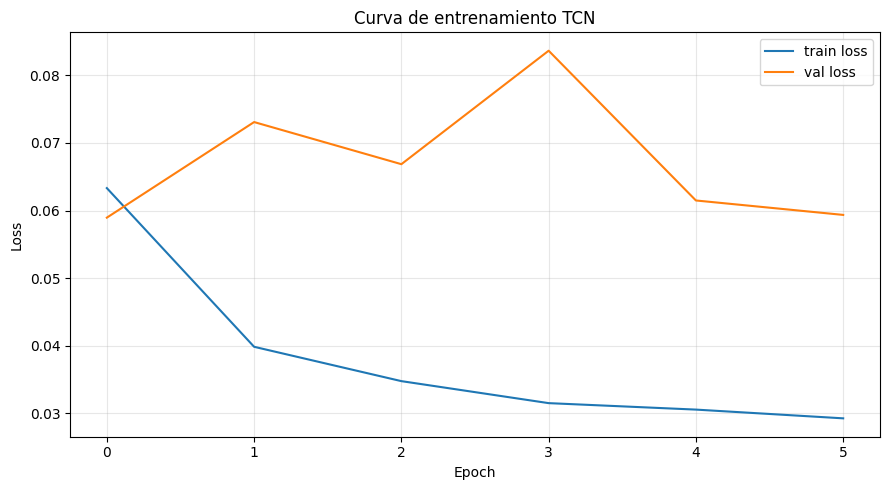

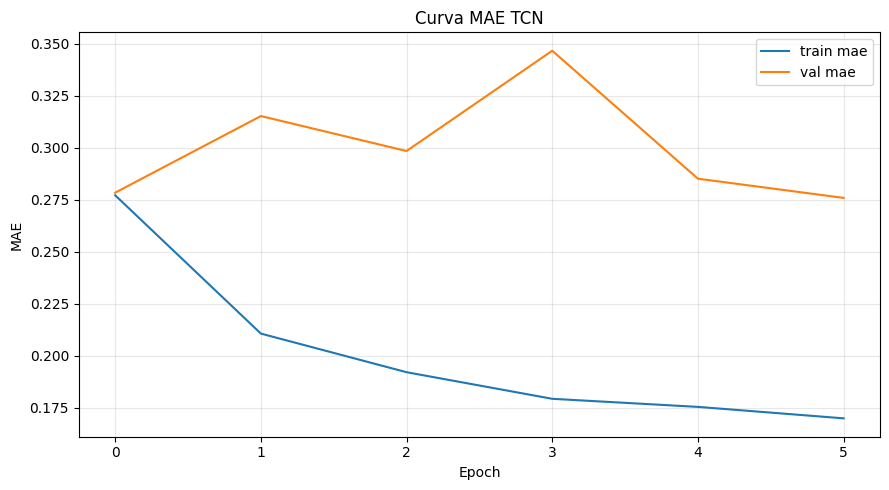

Modelo guardado:
/content/drive/MyDrive/AI Projects/DeepWave Canarias/models/tcn/tcn_best.keras
/content/drive/MyDrive/AI Projects/DeepWave Canarias/models/tcn/tcn_final.keras


In [11]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=max(2, PATIENCE // 2),
        min_lr=1e-5,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(MODELS_DIR / "tcn_best.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

# Guardar modelo final.
model.save(MODELS_DIR / "tcn_final.keras")

# Guardar history.
history_df = pd.DataFrame(history.history)
history_df.to_csv(RESULTS_DIR / "training_history.csv", index=False)

plot_history(history)

print("Modelo guardado:")
print(MODELS_DIR / "tcn_best.keras")
print(MODELS_DIR / "tcn_final.keras")

gc.collect()

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=max(2, PATIENCE // 2),
        min_lr=1e-5,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(MODELS_DIR / "tcn_best.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

# Guardar modelo final.
model.save(MODELS_DIR / "tcn_final.keras")

# Guardar history.
history_df = pd.DataFrame(history.history)
history_df.to_csv(RESULTS_DIR / "training_history.csv", index=False)

plot_history(history)

print("Modelo guardado:")
print(MODELS_DIR / "tcn_best.keras")
print(MODELS_DIR / "tcn_final.keras")

In [12]:
def predict_dataset(ds_split, meta_split, split_name):
    pred = model.predict(ds_split, verbose=1)
    pred = np.clip(pred, 0, None)

    out = meta_split.copy().reset_index(drop=True)

    if len(out) != pred.shape[0]:
        raise ValueError(f"Desalineación {split_name}: meta={len(out)}, pred={pred.shape[0]}")

    for i, h in enumerate(HORIZONS_HOURS):
        out[f"y_true_hs_{h}h"] = out[f"target_hs_{h}h"].values
        out[f"pred_tcn_hs_{h}h"] = pred[:, i]
        out[f"pred_persistence_hs_{h}h"] = out["persistence_hs"].values

        out[f"true_risk_{h}h"] = risk_level_from_hs(out[f"y_true_hs_{h}h"]).values
        out[f"pred_tcn_risk_{h}h"] = risk_level_from_hs(out[f"pred_tcn_hs_{h}h"]).values
        out[f"pred_persistence_risk_{h}h"] = risk_level_from_hs(out[f"pred_persistence_hs_{h}h"]).values

    out["split"] = split_name

    return out


val_predictions = predict_dataset(val_ds, val_meta, "val")
test_predictions = predict_dataset(test_ds, test_meta, "test")

predictions_all = pd.concat([val_predictions, test_predictions], ignore_index=True)

predictions_all.to_parquet(
    RESULTS_DIR / "val_test_predictions.parquet",
    index=False,
    engine="pyarrow",
    compression="snappy",
)

print("Predicciones:", predictions_all.shape)
display(predictions_all.head())

196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Predicciones: (65000, 36)


,zona_id,timestamp,split,isla,lat,lon,simar_hs,persistence_hs,target_hs_3h,target_hs_6h,...,pred_persistence_hs_12h,true_risk_12h,pred_tcn_risk_12h,pred_persistence_risk_12h,y_true_hs_24h,pred_tcn_hs_24h,pred_persistence_hs_24h,true_risk_24h,pred_tcn_risk_24h,pred_persistence_risk_24h
0,CAN_FV_GRAN_TARAJAL,2023-01-01 23:00:00+00:00,val,Fuerteventura,-0.622844,1.015967,-1.585977,-1.585977,0.38,0.39,...,-1.585977,0,0,0,0.42,0.543160,-1.585977,0,0,0
1,CAN_FV_GRAN_TARAJAL,2023-01-02 06:00:00+00:00,val,Fuerteventura,-0.622844,1.015967,-1.703866,-1.703866,0.44,0.48,...,-1.703866,0,0,0,0.87,0.411424,-1.703866,0,0,0
2,CAN_FV_GRAN_TARAJAL,2023-01-02 15:00:00+00:00,val,Fuerteventura,-0.622844,1.015967,-1.612174,-1.612174,0.44,0.42,...,-1.612174,0,0,0,1.19,0.307091,-1.612174,1,0,0
3,CAN_FV_GRAN_TARAJAL,2023-01-02 20:00:00+00:00,val,Fuerteventura,-0.622844,1.015967,-1.651471,-1.651471,0.42,0.48,...,-1.651471,0,0,0,0.99,0.304571,-1.651471,0,0,0
4,CAN_FV_GRAN_TARAJAL,2023-01-02 22:00:00+00:00,val,Fuerteventura,-0.622844,1.015967,-1.651471,-1.651471,0.45,0.67,...,-1.651471,1,0,0,0.96,0.317188,-1.651471,0,0,0


## Celda 12 — Métricas de regresión TCN

In [13]:
regression_rows = []

for split_name, pred_df in [
    ("val", val_predictions),
    ("test", test_predictions),
]:
    for h in HORIZONS_HOURS:
        y_true = pred_df[f"y_true_hs_{h}h"]
        pred_tcn = pred_df[f"pred_tcn_hs_{h}h"]
        pred_persistence = pred_df[f"pred_persistence_hs_{h}h"]

        m_tcn = regression_metrics(y_true, pred_tcn)
        m_pers = regression_metrics(y_true, pred_persistence)

        regression_rows.append(
            {
                "horizon_hours": h,
                "target": f"target_hs_{h}h",
                "split": split_name,
                "model": "TCN",
                **m_tcn,
            }
        )

        regression_rows.append(
            {
                "horizon_hours": h,
                "target": f"target_hs_{h}h",
                "split": split_name,
                "model": "Persistence",
                **m_pers,
            }
        )

regression_metrics_df = pd.DataFrame(regression_rows)
regression_metrics_df.to_csv(RESULTS_DIR / "metrics_regression.csv", index=False)

display(regression_metrics_df)

,horizon_hours,target,split,model,n,mae,rmse,r2,bias,corr
0,3,target_hs_3h,val,TCN,25000,0.231630,0.270857,0.865756,-0.222746,0.978032
1,3,target_hs_3h,val,Persistence,25000,1.679800,1.700613,-4.292075,-1.679800,0.986984
2,6,target_hs_6h,val,TCN,25000,0.277638,0.336207,0.793256,-0.264514,0.959977
3,6,target_hs_6h,val,Persistence,25000,1.679803,1.710682,-4.352502,-1.679788,0.962880
4,12,target_hs_12h,val,TCN,25000,0.258240,0.361114,0.762346,-0.188661,0.910395
5,12,target_hs_12h,val,Persistence,25000,1.681216,1.735929,-4.491849,-1.680476,0.903385
6,24,target_hs_24h,val,TCN,25000,0.345981,0.495482,0.556025,-0.220000,0.803563
7,24,target_hs_24h,val,Persistence,25000,1.687911,1.783972,-4.755452,-1.681603,0.787878
8,3,target_hs_3h,test,TCN,40000,0.230088,0.271685,0.887850,-0.217182,0.979610
9,3,target_hs_3h,test,Persistence,40000,1.655498,1.680757,-3.292171,-1.655209,0.987102


## Celda 13 — Métricas de riesgo derivado TCN

In [14]:
risk_rows = []

for split_name, pred_df in [
    ("val", val_predictions),
    ("test", test_predictions),
]:
    for h in HORIZONS_HOURS:
        y_true = pred_df[f"true_risk_{h}h"]
        pred_tcn = pred_df[f"pred_tcn_risk_{h}h"]
        pred_persistence = pred_df[f"pred_persistence_risk_{h}h"]

        m_tcn = classification_metrics(y_true, pred_tcn)
        m_pers = classification_metrics(y_true, pred_persistence)

        risk_rows.append(
            {
                "horizon_hours": h,
                "target": f"target_risk_{h}h",
                "split": split_name,
                "model": "TCN_risk_derived",
                **m_tcn,
            }
        )

        risk_rows.append(
            {
                "horizon_hours": h,
                "target": f"target_risk_{h}h",
                "split": split_name,
                "model": "PersistenceRisk",
                **m_pers,
            }
        )

        for model_name, pred_values in [
            ("TCN_risk_derived", pred_tcn),
            ("PersistenceRisk", pred_persistence),
        ]:
            yt = pd.Series(np.asarray(y_true), dtype="Int64")
            yp = pd.Series(np.asarray(pred_values), dtype="Int64")
            mask = yt.notna() & yp.notna()

            cm = confusion_matrix(
                yt[mask].astype(int),
                yp[mask].astype(int),
                labels=RISK_CLASSES,
            )

            pd.DataFrame(
                cm,
                index=[f"true_{i}" for i in RISK_CLASSES],
                columns=[f"pred_{i}" for i in RISK_CLASSES],
            ).to_csv(RESULTS_DIR / f"confusion_matrix_{model_name}_h{h}_{split_name}.csv")

risk_metrics_df = pd.DataFrame(risk_rows)
risk_metrics_df.to_csv(RESULTS_DIR / "metrics_risk.csv", index=False)

display(risk_metrics_df)

,horizon_hours,target,split,model,n,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_class_0,...,f1_class_1,support_class_1,precision_class_2,recall_class_2,f1_class_2,support_class_2,precision_class_3,recall_class_3,f1_class_3,support_class_3
0,3,target_risk_3h,val,TCN_risk_derived,25000,0.770720,0.758875,0.762457,0.770022,0.610239,...,0.794451,12920,0.896417,0.619262,0.732499,6666,0.966495,0.636672,0.767656,1178
1,3,target_risk_3h,val,PersistenceRisk,25000,0.175680,0.281498,0.139375,0.067596,0.200076,...,0.000250,12920,0.011667,0.001050,0.001927,6666,1.000000,0.124788,0.221887,1178
2,6,target_risk_6h,val,TCN_risk_derived,25000,0.720920,0.695957,0.699443,0.718006,0.563198,...,0.750685,12910,0.847119,0.546709,0.664540,6669,0.969305,0.506329,0.665188,1185
3,6,target_risk_6h,val,PersistenceRisk,25000,0.178360,0.283499,0.143017,0.072362,0.200076,...,0.002501,12910,0.093333,0.008397,0.015408,6669,1.000000,0.124051,0.220721,1185
4,12,target_risk_12h,val,TCN_risk_derived,25000,0.749480,0.704948,0.708270,0.744899,0.641373,...,0.788044,12862,0.808811,0.580722,0.676047,6702,0.761844,0.506383,0.608384,1175
5,12,target_risk_12h,val,PersistenceRisk,25000,0.188000,0.289044,0.153198,0.087986,0.201256,...,0.014552,12862,0.303333,0.027156,0.049849,6702,0.959184,0.120000,0.213313,1175
6,24,target_risk_24h,val,TCN_risk_derived,25000,0.686720,0.580258,0.590182,0.672403,0.631266,...,0.749609,12881,0.700204,0.461803,0.556548,6676,0.634312,0.230139,0.337740,1221
7,24,target_risk_24h,val,PersistenceRisk,25000,0.204240,0.289290,0.152393,0.116754,0.199367,...,0.059140,12881,0.541667,0.048682,0.089335,6676,0.598639,0.072072,0.128655,1221
8,3,target_risk_3h,test,TCN_risk_derived,40000,0.785650,0.786520,0.781315,0.784359,0.616456,...,0.818162,21008,0.868891,0.602232,0.711393,9948,0.977145,0.729556,0.835392,3106
9,3,target_risk_3h,test,PersistenceRisk,40000,0.163950,0.298796,0.157818,0.071135,0.179250,...,0.000000,21008,0.012610,0.002010,0.003468,9948,1.000000,0.193175,0.323799,3106


## Celda 14 — Comparativa principal TCN vs persistencia

In [15]:
test_reg = regression_metrics_df[regression_metrics_df["split"] == "test"].copy()
test_risk = risk_metrics_df[risk_metrics_df["split"] == "test"].copy()

display(test_reg)
display(test_risk)

# Mejora frente a persistencia.
improvement_rows = []

for h in HORIZONS_HOURS:
    subset = test_reg[test_reg["horizon_hours"] == h]

    tcn_row = subset[subset["model"] == "TCN"].iloc[0]
    pers_row = subset[subset["model"] == "Persistence"].iloc[0]

    improvement_rows.append(
        {
            "horizon_hours": h,
            "mae_persistence": pers_row["mae"],
            "mae_tcn": tcn_row["mae"],
            "mae_improvement_pct": (pers_row["mae"] - tcn_row["mae"]) / pers_row["mae"] * 100 if pers_row["mae"] > 0 else np.nan,
            "rmse_persistence": pers_row["rmse"],
            "rmse_tcn": tcn_row["rmse"],
            "rmse_improvement_pct": (pers_row["rmse"] - tcn_row["rmse"]) / pers_row["rmse"] * 100 if pers_row["rmse"] > 0 else np.nan,
            "r2_tcn": tcn_row["r2"],
            "corr_tcn": tcn_row["corr"],
        }
    )

improvement_df = pd.DataFrame(improvement_rows)
improvement_df.to_csv(RESULTS_DIR / "test_improvement_vs_persistence.csv", index=False)

display(improvement_df)

,horizon_hours,target,split,model,n,mae,rmse,r2,bias,corr
8,3,target_hs_3h,test,TCN,40000,0.230088,0.271685,0.887850,-0.217182,0.979610
9,3,target_hs_3h,test,Persistence,40000,1.655498,1.680757,-3.292171,-1.655209,0.987102
10,6,target_hs_6h,test,TCN,40000,0.282668,0.345560,0.818071,-0.265577,0.962101
11,6,target_hs_6h,test,Persistence,40000,1.655699,1.692832,-3.366002,-1.654367,0.962123
12,12,target_hs_12h,test,TCN,40000,0.276380,0.388966,0.769790,-0.193123,0.910360
13,12,target_hs_12h,test,Persistence,40000,1.660427,1.726075,-3.533363,-1.654878,0.896987
14,24,target_hs_24h,test,TCN,40000,0.376210,0.545984,0.545324,-0.240275,0.797203
15,24,target_hs_24h,test,Persistence,40000,1.676028,1.789935,-3.886714,-1.655151,0.767150


,horizon_hours,target,split,model,n,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_class_0,...,f1_class_1,support_class_1,precision_class_2,recall_class_2,f1_class_2,support_class_2,precision_class_3,recall_class_3,f1_class_3,support_class_3
8,3,target_risk_3h,test,TCN_risk_derived,40000,0.785650,0.786520,0.781315,0.784359,0.616456,...,0.818162,21008,0.868891,0.602232,0.711393,9948,0.977145,0.729556,0.835392,3106
9,3,target_risk_3h,test,PersistenceRisk,40000,0.163950,0.298796,0.157818,0.071135,0.179250,...,0.000000,21008,0.012610,0.002010,0.003468,9948,1.000000,0.193175,0.323799,3106
10,6,target_risk_6h,test,TCN_risk_derived,40000,0.732600,0.723003,0.716761,0.729283,0.562788,...,0.776523,20975,0.799147,0.525536,0.634084,9986,0.964712,0.598905,0.739018,3104
11,6,target_risk_6h,test,PersistenceRisk,40000,0.167825,0.302348,0.163871,0.077833,0.179159,...,0.002572,20975,0.091425,0.014520,0.025060,9986,1.000000,0.193299,0.323974,3104
12,12,target_risk_12h,test,TCN_risk_derived,40000,0.748575,0.717688,0.716463,0.742605,0.638305,...,0.802269,20851,0.751619,0.542940,0.630460,10049,0.820395,0.572987,0.674726,3117
13,12,target_risk_12h,test,PersistenceRisk,40000,0.180575,0.309989,0.177544,0.098078,0.180608,...,0.016916,20851,0.281841,0.044482,0.076837,10049,0.961667,0.185114,0.310465,3117
14,24,target_risk_24h,test,TCN_risk_derived,40000,0.675325,0.589930,0.593065,0.658052,0.627558,...,0.757745,20959,0.598101,0.415094,0.490070,10017,0.677171,0.285483,0.401641,3086
15,24,target_risk_24h,test,PersistenceRisk,40000,0.199925,0.314007,0.184091,0.131677,0.179099,...,0.066209,20959,0.498739,0.078966,0.136344,10017,0.706667,0.137395,0.230060,3086


,horizon_hours,mae_persistence,mae_tcn,mae_improvement_pct,rmse_persistence,rmse_tcn,rmse_improvement_pct,r2_tcn,corr_tcn
0,3,1.655498,0.230088,86.101602,1.680757,0.271685,83.835548,0.887850,0.979610
1,6,1.655699,0.282668,82.927585,1.692832,0.345560,79.586890,0.818071,0.962101
2,12,1.660427,0.276380,83.354856,1.726075,0.388966,77.465288,0.769790,0.910360
3,24,1.676028,0.376210,77.553475,1.789935,0.545984,69.497015,0.545324,0.797203


## Celda 15 — Gráficos de métricas TCN

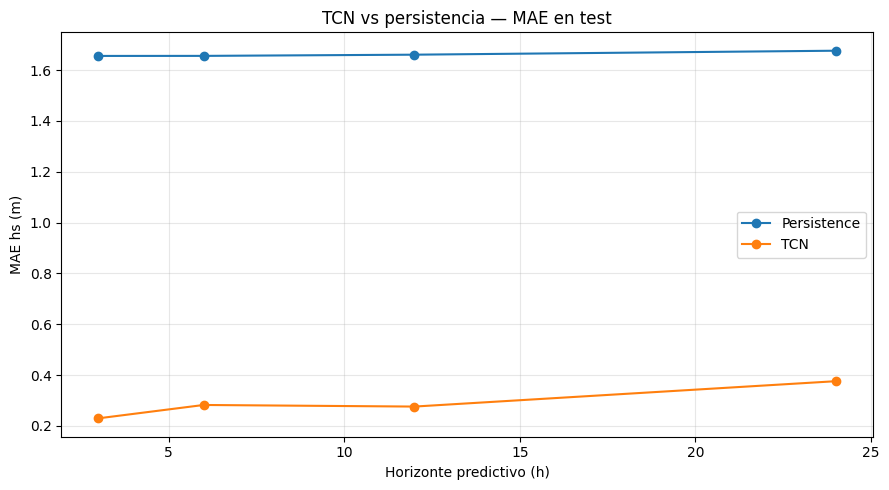

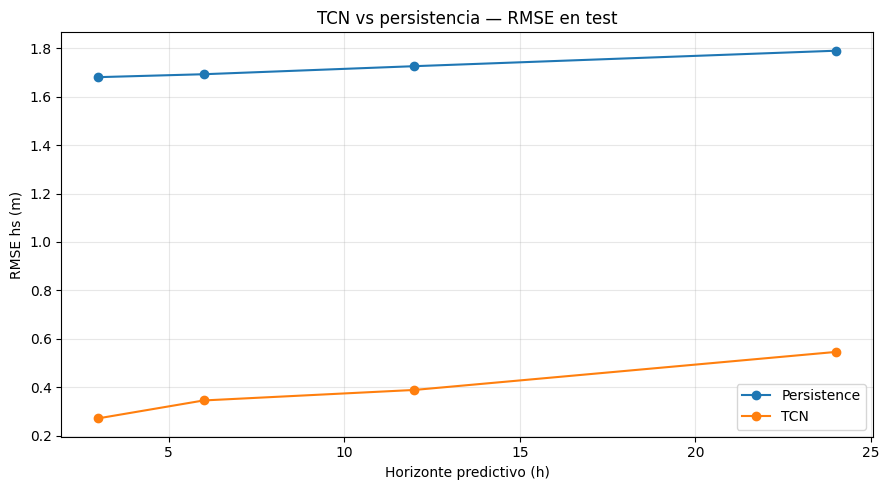

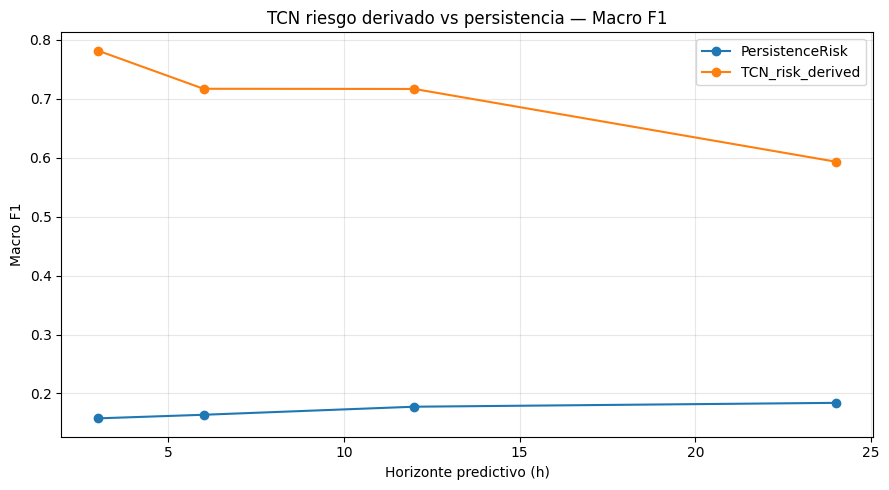

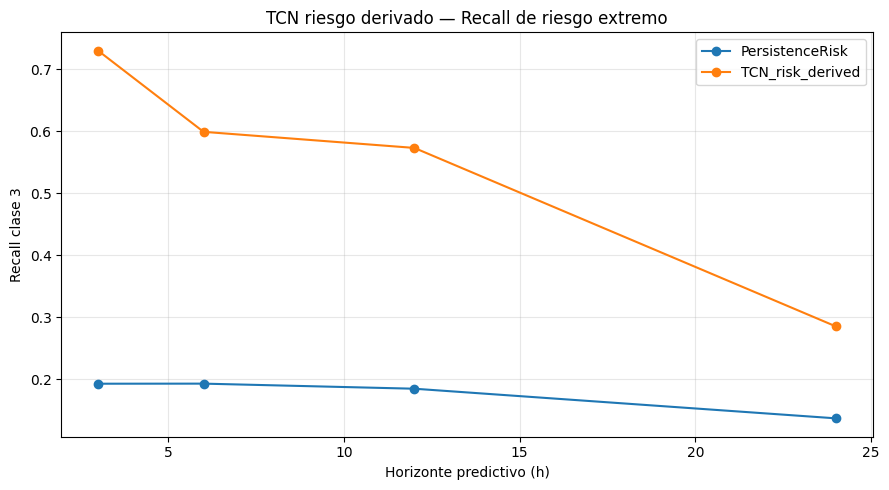

In [16]:
plt.figure(figsize=(9, 5))

for model_name in ["Persistence", "TCN"]:
    data = test_reg[test_reg["model"] == model_name].sort_values("horizon_hours")
    plt.plot(data["horizon_hours"], data["mae"], marker="o", label=model_name)

plt.xlabel("Horizonte predictivo (h)")
plt.ylabel("MAE hs (m)")
plt.title("TCN vs persistencia — MAE en test")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "plot_test_mae_by_horizon.png", dpi=160)
plt.show()

plt.figure(figsize=(9, 5))

for model_name in ["Persistence", "TCN"]:
    data = test_reg[test_reg["model"] == model_name].sort_values("horizon_hours")
    plt.plot(data["horizon_hours"], data["rmse"], marker="o", label=model_name)

plt.xlabel("Horizonte predictivo (h)")
plt.ylabel("RMSE hs (m)")
plt.title("TCN vs persistencia — RMSE en test")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "plot_test_rmse_by_horizon.png", dpi=160)
plt.show()

plt.figure(figsize=(9, 5))

for model_name in ["PersistenceRisk", "TCN_risk_derived"]:
    data = test_risk[test_risk["model"] == model_name].sort_values("horizon_hours")
    plt.plot(data["horizon_hours"], data["macro_f1"], marker="o", label=model_name)

plt.xlabel("Horizonte predictivo (h)")
plt.ylabel("Macro F1")
plt.title("TCN riesgo derivado vs persistencia — Macro F1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "plot_test_macro_f1_risk.png", dpi=160)
plt.show()

plt.figure(figsize=(9, 5))

for model_name in ["PersistenceRisk", "TCN_risk_derived"]:
    data = test_risk[test_risk["model"] == model_name].sort_values("horizon_hours")
    plt.plot(data["horizon_hours"], data["recall_class_3"], marker="o", label=model_name)

plt.xlabel("Horizonte predictivo (h)")
plt.ylabel("Recall clase 3")
plt.title("TCN riesgo derivado — Recall de riesgo extremo")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "plot_test_recall_class_3.png", dpi=160)
plt.show()

## Celda 16 — Comparación opcional contra LightGBM y XGBoost

,horizon_hours,target,split,model,n,mae,rmse,r2,bias,corr
0,3,target_hs_3h,test,LightGBMRegressor,174135,0.062603,0.099376,0.984963,-0.000656,0.992545
1,3,target_hs_3h,test,Persistence,174135,0.089138,0.130027,0.974257,0.000349,0.987132
2,6,target_hs_6h,test,LightGBMRegressor,173958,0.115955,0.170217,0.955884,0.000212,0.978034
3,6,target_hs_6h,test,Persistence,173958,0.155820,0.224067,0.923556,0.000729,0.961796
4,12,target_hs_12h,test,LightGBMRegressor,173604,0.208555,0.297417,0.865371,0.000439,0.931078
5,12,target_hs_12h,test,Persistence,173604,0.255759,0.368320,0.793529,0.001481,0.896824
6,24,target_hs_24h,test,LightGBMRegressor,173376,0.330201,0.460345,0.677494,-0.009273,0.824775
7,24,target_hs_24h,test,Persistence,173376,0.387839,0.554102,0.532749,0.001743,0.766396
8,3,target_hs_3h,test,TCN,40000,0.230088,0.271685,0.887850,-0.217182,0.979610
9,6,target_hs_6h,test,TCN,40000,0.282668,0.345560,0.818071,-0.265577,0.962101


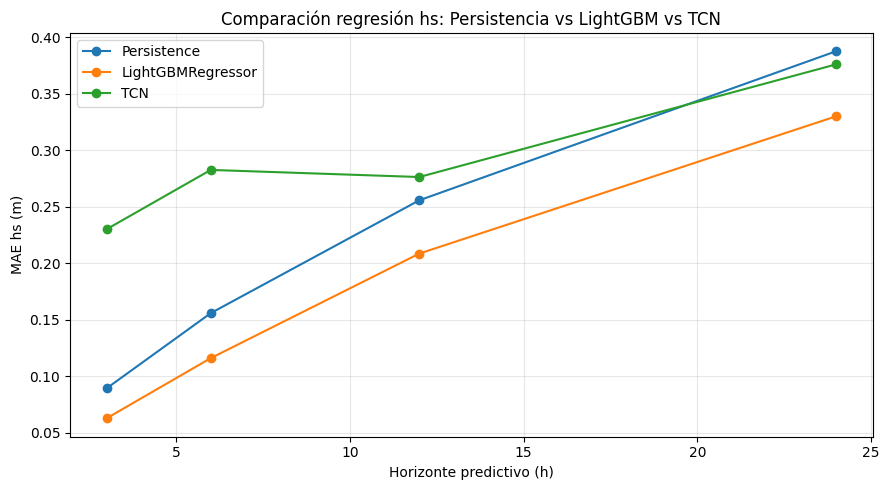

,horizon_hours,target,split,model,n,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_class_0,...,f1_class_1,support_class_1,precision_class_2,recall_class_2,f1_class_2,support_class_2,precision_class_3,recall_class_3,f1_class_3,support_class_3
0,3,target_risk_3h,test,LightGBMRegressor_risk_derived,174135,0.944767,0.934673,0.939179,0.944729,0.941726,...,0.956700,91327,0.925868,0.927224,0.926546,43696,0.954737,0.917236,0.935611,13315
1,6,target_risk_6h,test,LightGBMRegressor_risk_derived,173958,0.896803,0.871643,0.883351,0.896622,0.912334,...,0.921302,91245,0.851217,0.867681,0.859370,43637,0.909826,0.821012,0.863140,13297
2,12,target_risk_12h,test,LightGBMRegressor_risk_derived,173604,0.814929,0.762452,0.785569,0.814217,0.866451,...,0.860826,91061,0.723821,0.771673,0.746982,43534,0.832505,0.643482,0.725889,13270
3,24,target_risk_24h,test,LightGBMRegressor_risk_derived,173376,0.704342,0.596647,0.629172,0.698370,0.819444,...,0.782875,90914,0.560411,0.635241,0.595484,43489,0.714132,0.299902,0.422411,13261
4,3,target_risk_3h,test,XGBClassifier_direct_risk,174135,0.934775,0.946344,0.930576,0.935083,0.892036,...,0.946876,91327,0.896956,0.932694,0.914476,43696,0.903854,0.958092,0.930183,13315
5,6,target_risk_6h,test,XGBClassifier_direct_risk,173958,0.878315,0.894486,0.869121,0.879333,0.823482,...,0.901750,91245,0.807403,0.870294,0.837669,43637,0.814635,0.895014,0.852935,13297
6,12,target_risk_12h,test,XGBClassifier_direct_risk,173604,0.786606,0.798065,0.766844,0.789471,0.749857,...,0.828752,91061,0.667319,0.767906,0.714087,43534,0.661625,0.744989,0.700837,13270
7,24,target_risk_24h,test,XGBClassifier_direct_risk,173376,0.649848,0.665456,0.622502,0.657363,0.681807,...,0.708541,90914,0.502423,0.605440,0.549142,43489,0.405333,0.597165,0.482895,13261
8,3,target_risk_3h,test,PersistenceRisk,174135,0.918489,0.909337,0.909224,0.918493,0.918590,...,0.937561,91327,0.885610,0.886077,0.885843,43696,0.894547,0.895757,0.895152,13315
9,6,target_risk_6h,test,PersistenceRisk,173958,0.858684,0.841002,0.840787,0.858706,0.863943,...,0.893297,91245,0.798755,0.799780,0.799267,43637,0.805970,0.808152,0.807060,13297


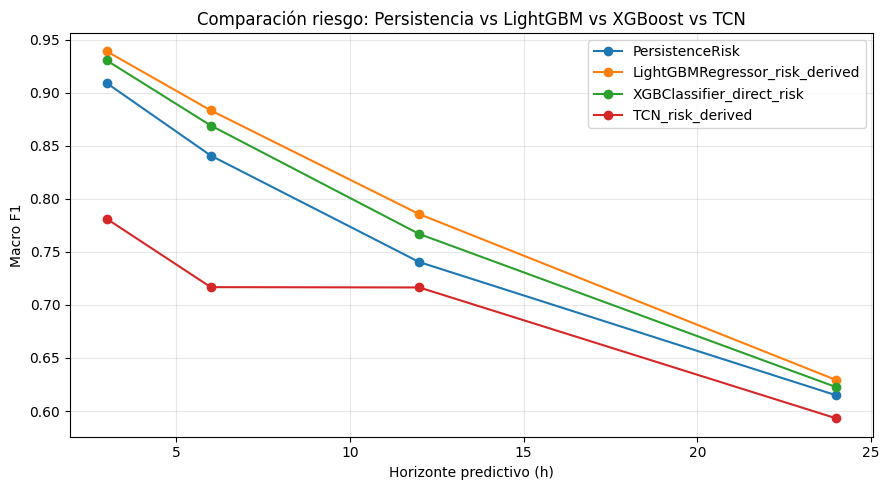

In [17]:
COMPARISON_DIR = GOLD_DIR / "model_results" / "model_comparison"

comparison_available = COMPARISON_DIR.exists()

if comparison_available:
    lgbm_reg_path = COMPARISON_DIR / "lgbm_regression_metrics_recalculated.csv"
    risk_comp_path = COMPARISON_DIR / "comparison_risk_metrics.csv"

    if lgbm_reg_path.exists():
        lgbm_reg = pd.read_csv(lgbm_reg_path)
        lgbm_reg_test = lgbm_reg[lgbm_reg["split"] == "test"].copy()

        combined_reg = pd.concat(
            [
                lgbm_reg_test[lgbm_reg_test["model"].isin(["LightGBMRegressor", "Persistence"])],
                test_reg[test_reg["model"] == "TCN"],
            ],
            ignore_index=True,
        )

        combined_reg.to_csv(RESULTS_DIR / "comparison_regression_tcn_lightgbm.csv", index=False)

        display(combined_reg)

        plt.figure(figsize=(9, 5))
        for model_name in ["Persistence", "LightGBMRegressor", "TCN"]:
            data = combined_reg[combined_reg["model"] == model_name].sort_values("horizon_hours")
            plt.plot(data["horizon_hours"], data["mae"], marker="o", label=model_name)

        plt.xlabel("Horizonte predictivo (h)")
        plt.ylabel("MAE hs (m)")
        plt.title("Comparación regresión hs: Persistencia vs LightGBM vs TCN")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / "plot_compare_mae_lightgbm_tcn.png", dpi=160)
        plt.show()

    if risk_comp_path.exists():
        risk_comp = pd.read_csv(risk_comp_path)
        risk_comp_test = risk_comp[risk_comp["split"] == "test"].copy()

        combined_risk = pd.concat(
            [
                risk_comp_test,
                test_risk[test_risk["model"] == "TCN_risk_derived"],
            ],
            ignore_index=True,
        )

        combined_risk.to_csv(RESULTS_DIR / "comparison_risk_tcn_lightgbm_xgb.csv", index=False)

        display(combined_risk)

        plt.figure(figsize=(9, 5))
        for model_name in [
            "PersistenceRisk",
            "LightGBMRegressor_risk_derived",
            "XGBClassifier_direct_risk",
            "TCN_risk_derived",
        ]:
            data = combined_risk[combined_risk["model"] == model_name].sort_values("horizon_hours")
            if data.empty:
                continue
            plt.plot(data["horizon_hours"], data["macro_f1"], marker="o", label=model_name)

        plt.xlabel("Horizonte predictivo (h)")
        plt.ylabel("Macro F1")
        plt.title("Comparación riesgo: Persistencia vs LightGBM vs XGBoost vs TCN")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / "plot_compare_risk_macro_f1_all_models.png", dpi=160)
        plt.show()

else:
    print("No existe model_comparison/. Se omite comparación externa.")

## Celda 17 — Guardar configuración del experimento

In [18]:
training_config = {
    "model_family": "TCN",
    "task": "multi_horizon_wave_height_regression",
    "risk_derivation": "thresholds_from_predicted_hs",
    "horizons_hours": HORIZONS_HOURS,
    "target_cols": TARGET_COLS,
    "sequence_length": SEQUENCE_LENGTH,
    "batch_size": BATCH_SIZE,
    "epochs_requested": EPOCHS,
    "patience": PATIENCE,
    "features_count": len(feature_cols),
    "feature_cols": feature_cols,
    "categorical_features": categorical_features,
    "encoded_categorical_features": encoded_categorical_features,
    "use_common_zones_only": USE_COMMON_ZONES_ONLY,
    "common_zones_count": len(common_zones),
    "common_zones": sorted(list(common_zones)),
    "max_train_sequences": MAX_TRAIN_SEQUENCES,
    "max_val_sequences": MAX_VAL_SEQUENCES,
    "max_test_sequences": MAX_TEST_SEQUENCES,
    "risk_thresholds": RISK_THRESHOLDS,
    "model_paths": {
        "best": str(MODELS_DIR / "tcn_best.keras"),
        "final": str(MODELS_DIR / "tcn_final.keras"),
    },
}

save_json(training_config, RESULTS_DIR / "training_config.json")
save_json(training_config, MODELS_DIR / "training_config.json")

print("Configuración guardada.")
print(RESULTS_DIR / "training_config.json")
print(MODELS_DIR / "training_config.json")

Configuración guardada.
/content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/tcn/training_config.json
/content/drive/MyDrive/AI Projects/DeepWave Canarias/models/tcn/training_config.json


## Celda 18 — Validación final

In [19]:
required_files = [
    MODELS_DIR / "tcn_best.keras",
    MODELS_DIR / "tcn_final.keras",
    RESULTS_DIR / "training_history.csv",
    RESULTS_DIR / "metrics_regression.csv",
    RESULTS_DIR / "metrics_risk.csv",
    RESULTS_DIR / "val_test_predictions.parquet",
    RESULTS_DIR / "test_improvement_vs_persistence.csv",
    RESULTS_DIR / "training_config.json",
    RESULTS_DIR / "tcn_feature_scaler_metadata.json",
]

missing = [str(p) for p in required_files if not Path(p).exists()]

if missing:
    raise FileNotFoundError("Faltan archivos de salida: " + json.dumps(missing, indent=2))

test_tcn = regression_metrics_df[
    (regression_metrics_df["split"] == "test")
    & (regression_metrics_df["model"] == "TCN")
]

if test_tcn["horizon_hours"].nunique() != len(HORIZONS_HOURS):
    raise ValueError("No hay métricas test TCN para todos los horizontes.")

if test_tcn["mae"].isna().any() or test_tcn["rmse"].isna().any():
    raise ValueError("Hay métricas MAE/RMSE nulas en test.")

print("Archivos generados en", RESULTS_DIR)
for p in sorted(RESULTS_DIR.glob("*")):
    print("-", p)

print("\nModelos generados en", MODELS_DIR)
for p in sorted(MODELS_DIR.glob("*")):
    print("-", p)

print("\nResumen test TCN:")
display(test_tcn)

print("\n✅ Entrenamiento TCN completado correctamente.")

Archivos generados en /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/tcn
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/tcn/comparison_regression_tcn_lightgbm.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/tcn/comparison_risk_tcn_lightgbm_xgb.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/tcn/confusion_matrix_PersistenceRisk_h12_test.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/tcn/confusion_matrix_PersistenceRisk_h12_val.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/tcn/confusion_matrix_PersistenceRisk_h24_test.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/tcn/confusion_matrix_PersistenceRisk_h24_val.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/tcn/confusion_matrix_PersistenceRisk_h3_test.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canaria

,horizon_hours,target,split,model,n,mae,rmse,r2,bias,corr
8,3,target_hs_3h,test,TCN,40000,0.230088,0.271685,0.887850,-0.217182,0.979610
10,6,target_hs_6h,test,TCN,40000,0.282668,0.345560,0.818071,-0.265577,0.962101
12,12,target_hs_12h,test,TCN,40000,0.276380,0.388966,0.769790,-0.193123,0.910360
14,24,target_hs_24h,test,TCN,40000,0.376210,0.545984,0.545324,-0.240275,0.797203



✅ Entrenamiento TCN completado correctamente.


## Resultado esperado

Al final debe aparecer:

```text
✅ Entrenamiento TCN completado correctamente.
```

Archivos principales:

```text
models/tcn/tcn_best.keras
models/tcn/tcn_final.keras

gold/model_results/tcn/metrics_regression.csv
gold/model_results/tcn/metrics_risk.csv
gold/model_results/tcn/val_test_predictions.parquet
gold/model_results/tcn/test_improvement_vs_persistence.csv
gold/model_results/tcn/training_history.csv
gold/model_results/tcn/comparison_regression_tcn_lightgbm.csv
gold/model_results/tcn/comparison_risk_tcn_lightgbm_xgb.csv
```

Interpretación:

```text
- Si TCN supera a LightGBM en MAE/RMSE, será candidato a modelo final de hs.
- Si no lo supera, sigue siendo útil como comparación deep learning.
- Si mejora recall extremo, puede ser candidato para un ensemble.
```

Siguiente paso:

```text
13B_model_comparison_tcn_classical.ipynb
```

o directamente actualizar el informe final con los resultados TCN.